# Data Analysis Project On DMart Sales Data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

## Loading the D Mart Data Set

In [53]:
df = pd.read_csv("DMart_sample_data_modified_64k.csv")

Getting a view of the data set

In [54]:
df.head()

,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName
0,30-08-2024 06:07,16:06:50,Regular,Electronics,142.494909,2,284.99,Avani Iyer
1,22-02-2023 19:48,22:51:46,Regular,Home & Kitchen,462.398027,1,462.40,Tanvi Jain
2,13-05-2024 04:29,11:48:46,Regular,Clothing,64.137199,5,320.69,Eeshaan Patel
3,27-12-2023 16:09,02:34:39,Premium,Clothing,114.809421,2,229.62,Eeshaan Kumar
4,05-07-2024 23:40,10:22:35,Premium,Home & Kitchen,120.361725,1,120.36,Gaurav Rao


## Dataset Overview

Before diving into analysis, let's understand the structure of the dataset.
We check the data types, number of entries, and overall dimensions.

In [4]:
# Inspect structure and datatypes 
# Display basic dataset information ( column names , non-null counts ,data types )
print("\nDataSet Info :")
df.info()

# Print dataset shape (number of rows and columns)
print("\nDataSet shape(rows,columns):")
df.shape


DataSet Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             64000 non-null  object 
 1   Time             64000 non-null  object 
 2   CustomerType     64000 non-null  object 
 3   ProductCategory  64000 non-null  object 
 4   UnitPrice        64000 non-null  float64
 5   Quantity         64000 non-null  int64  
 6   Total            64000 non-null  float64
 7   FullName         64000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.9+ MB

DataSet shape(rows,columns):


(64000, 8)

In [5]:
# Check for missing values
# ----------------------------------------
print("\n Missing Values:")
print(df.isnull().sum())


 Missing Values:
Date               0
Time               0
CustomerType       0
ProductCategory    0
UnitPrice          0
Quantity           0
Total              0
FullName           0
dtype: int64


## Output Summary 

- No missing values detected in any column.
- The dataset is clean in terms of null entries and ready for further preprocessing. ✅

In [6]:
# Handle duplicates
# ---------------------------------
print("\nDuplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate rows: 0


## Output Summary


- Duplicate Rows Found: 0
- No duplicates exist, so the dataset remains unchanged. ✅


In [7]:
# Feature Engineering 

#  DateTime parsing and time features
# ------------------------------------------
# Combine 'Date' and 'Time' columns 
print("\n Creating 'DateTime' and extracting time-based features...")
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)




 Creating 'DateTime' and extracting time-based features...


C:\Users\user\AppData\Local\Temp\ipykernel_18844\172115910.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)


### Output Summary

- A new column DateTime is created.
- Further features (Day, Month, Weekday, Hour) can now be extracted for analysis.
- Reason: There is also time mentioned in the Date column by we only need the time of transaction i.e. Time column. So we created a new column and it will be treated as the primary Date-Time column.

df.head()

In [8]:

# --------------------------------------------------
# Extract Individual Time-based Features
# --------------------------------------------------

# Extract the day of the week (e.g., Monday, Tuesday)
df['DayOfWeek'] = df['DateTime'].dt.day_name()

# Extract the month name (e.g., January, February)
df['Month'] = df['DateTime'].dt.month_name()

# Extract the hour of the day (0–23)
df['Hour'] = df['DateTime'].dt.hour

### Output Summary:

- DayOfWeek, Month, and Hour columns added to the dataset.
- These features enable analysis of shopping patterns across days, months, and hours.

In [9]:
df.head()

,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName,DateTime,DayOfWeek,Month,Hour
0,30-08-2024 06:07,16:06:50,Regular,Electronics,142.494909,2,284.99,Avani Iyer,2024-08-30 16:06:50,Friday,August,16
1,22-02-2023 19:48,22:51:46,Regular,Home & Kitchen,462.398027,1,462.40,Tanvi Jain,2023-02-22 22:51:46,Wednesday,February,22
2,13-05-2024 04:29,11:48:46,Regular,Clothing,64.137199,5,320.69,Eeshaan Patel,2024-05-13 11:48:46,Monday,May,11
3,27-12-2023 16:09,02:34:39,Premium,Clothing,114.809421,2,229.62,Eeshaan Kumar,2023-12-27 02:34:39,Wednesday,December,2
4,05-07-2024 23:40,10:22:35,Premium,Home & Kitchen,120.361725,1,120.36,Gaurav Rao,2024-07-05 10:22:35,Friday,July,10


In [10]:

# Feature Engineering
# -----------------------------
# Revenue per unit
print("\n📌 Calculating Revenue Per Unit...")
df['RevenuePerUnit'] = df['Total'] / df['Quantity']


📌 Calculating Revenue Per Unit...


In [11]:
df.head()

,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName,DateTime,DayOfWeek,Month,Hour,RevenuePerUnit
0,30-08-2024 06:07,16:06:50,Regular,Electronics,142.494909,2,284.99,Avani Iyer,2024-08-30 16:06:50,Friday,August,16,142.495
1,22-02-2023 19:48,22:51:46,Regular,Home & Kitchen,462.398027,1,462.40,Tanvi Jain,2023-02-22 22:51:46,Wednesday,February,22,462.400
2,13-05-2024 04:29,11:48:46,Regular,Clothing,64.137199,5,320.69,Eeshaan Patel,2024-05-13 11:48:46,Monday,May,11,64.138
3,27-12-2023 16:09,02:34:39,Premium,Clothing,114.809421,2,229.62,Eeshaan Kumar,2023-12-27 02:34:39,Wednesday,December,2,114.810
4,05-07-2024 23:40,10:22:35,Premium,Home & Kitchen,120.361725,1,120.36,Gaurav Rao,2024-07-05 10:22:35,Friday,July,10,120.360


### Another Feature Engineering – Revenue Per Unit

- To gain more insights, we calculate Revenue Per Unit:
- This feature helps us understand the average selling price per product unit across transactions.

In [12]:
# High spender flag
print("\n Flagging high spenders...")
avg_total = df['Total'].mean()
df['HighSpender'] = df['Total'] > avg_total


 Flagging high spenders...


###  Feature Engineering – High Spender Flag - A binary feature

To differentiate between regular customers and big spenders,
we create a new feature HighSpender based on the transaction amount.

- First, compute the average transaction value
- Then, label transactions as True (High Spender) if Total > Average, otherwise False.

In [13]:
# --------------------------------------------------
# 📌 Final Data Preview
# --------------------------------------------------

print("\n📌 Final Data Preview:")

# Display the first 10 rows of the transformed dataset
display(df.head(10))
print("Now the Shape of the data: ",df.shape)


📌 Final Data Preview:


,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName,DateTime,DayOfWeek,Month,Hour,RevenuePerUnit,HighSpender
0,30-08-2024 06:07,16:06:50,Regular,Electronics,142.494909,2,284.99,Avani Iyer,2024-08-30 16:06:50,Friday,August,16,142.495000,False
1,22-02-2023 19:48,22:51:46,Regular,Home & Kitchen,462.398027,1,462.40,Tanvi Jain,2023-02-22 22:51:46,Wednesday,February,22,462.400000,False
2,13-05-2024 04:29,11:48:46,Regular,Clothing,64.137199,5,320.69,Eeshaan Patel,2024-05-13 11:48:46,Monday,May,11,64.138000,False
3,27-12-2023 16:09,02:34:39,Premium,Clothing,114.809421,2,229.62,Eeshaan Kumar,2023-12-27 02:34:39,Wednesday,December,2,114.810000,False
4,05-07-2024 23:40,10:22:35,Premium,Home & Kitchen,120.361725,1,120.36,Gaurav Rao,2024-07-05 10:22:35,Friday,July,10,120.360000,False
5,22-02-2023 10:48,12:43:55,Premium,Beauty & Personal Care,96.750682,4,387.00,Ishaan Lal,2023-02-22 12:43:55,Wednesday,February,12,96.750000,False
6,15-08-2024 12:48,12:06:43,Member,Grocery,535.019168,1,535.02,Mahesh Sharma,2024-08-15 12:06:43,Thursday,August,12,535.020000,False
7,03-01-2024 03:03,17:54:41,Member,Beauty & Personal Care,155.372435,1,155.37,Shreya Xavier,2024-01-03 17:54:41,Wednesday,January,17,155.370000,False
8,02-09-2023 14:10,13:47:08,Premium,Home & Kitchen,27.556293,5,137.78,Avani Khanna,2023-09-02 13:47:08,Saturday,September,13,27.556000,False
9,12-08-2023 15:25,09:00:01,Regular,Electronics,451.351912,3,1354.06,Uday Lal,2023-08-12 09:00:01,Saturday,August,9,451.353333,True


Now the Shape of the data:  (64000, 14)


### Univariate Data Analysis

Univariate analysis helps us understand the distribution and frequency of individual features.
We will explore both categorical and numerical variables separately.

In [14]:
# Column groups
numeric_cols = ['UnitPrice', 'Quantity', 'Total', 'UnitPrice']
categorical_cols = ['CustomerType', 'ProductCategory', 'FullName', 'DayOfWeek', 'Month', 'HighSpender']
datetime_cols = ['Date', 'Time', 'DateTime', 'Hour']

### 1. Numeric Variables

In [15]:
# Loop through numerical columns and display summary stats
for col in numeric_cols:
    print(f"\n===== {col} =====")
    print(df[col].describe())
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


===== UnitPrice =====
count    64000.000000
mean       255.830513
std        149.447581
min          7.115927
25%        129.605829
50%        249.573154
75%        369.240107
max        702.831683
Name: UnitPrice, dtype: float64
Skewness: 0.2564981428786978
Kurtosis: -0.8022617860136276

===== Quantity =====
count    64000.000000
mean         3.005594
std          1.661893
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          8.000000
Name: Quantity, dtype: float64
Skewness: 0.5388636816757838
Kurtosis: -0.517882345604149

===== Total =====
count    64000.000000
mean       768.299728
std        664.712837
min          7.460000
25%        271.597500
50%        554.965000
75%       1093.332500
max       4724.650000
Name: Total, dtype: float64
Skewness: 1.3784646286273492
Kurtosis: 1.9189207324786612

===== UnitPrice =====
count    64000.000000
mean       255.830513
std        149.447581
min          7.115927
25%        129.605829
50%      

### Univariate Analysis – Numerical Features

For each numerical variable, we calculate:

- Summary statistics (count, mean, std, min, quartiles, max)
- Skewness → symmetry of distribution
- Kurtosis → presence of heavy/light tails in distribution

### Analysis:

 Univariate Analysis – Numerical Features (Summary & Insights)

####  UnitPrice

- Mean: 255.8, Median: 249.6 → fairly close (distribution is almost symmetric).
- Skewness: 0.25 → slight right skew.
- Kurtosis: -0.80 → light tails, fewer extreme outliers than a normal distribution.


✅ Interpretation: Prices are fairly evenly distributed, centered around ₹250, with few extreme highs.

####  Quantity

- Mean: 3.0, Median: 3 → very close, indicates balanced distribution.
- Skewness: 0.54 → moderate right skew.
- Kurtosis: -0.52 → light tails, no heavy outliers.

✅ Interpretation: Most customers purchase 2–4 items per transaction.

 #### Total

- Mean: 768.3, Median: 554.9 → mean higher than median → right skew.
- Skewness: 1.37 → strongly right-skewed (a few very large bills).
- Kurtosis: 1.92 → heavier tails than normal distribution.

✅ Interpretation: Most transactions are under ₹1100, but a few big spenders push the mean higher.

#### RevenuePerUnit

- Expected: Right-skewed, since a few high-value items dominate.

✅ Interpretation: Useful for spotting premium product categories.


===== UnitPrice =====


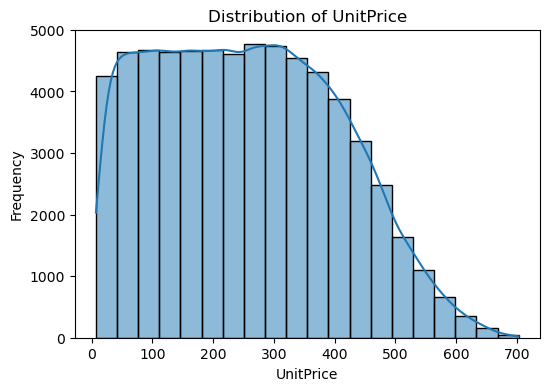

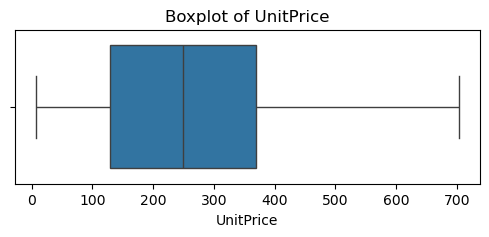


===== Quantity =====


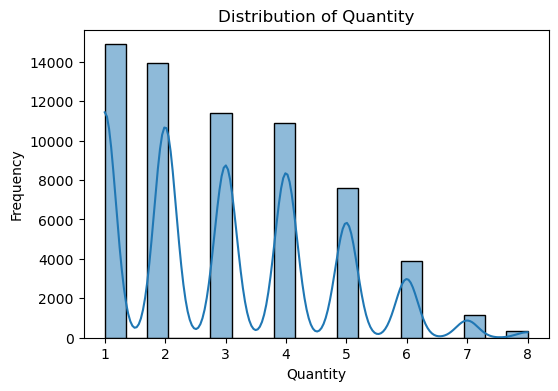

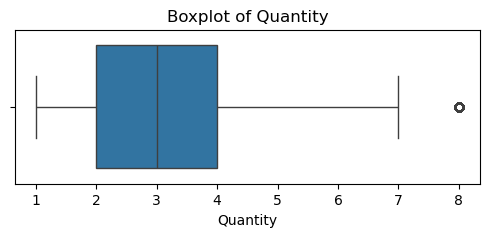


===== Total =====


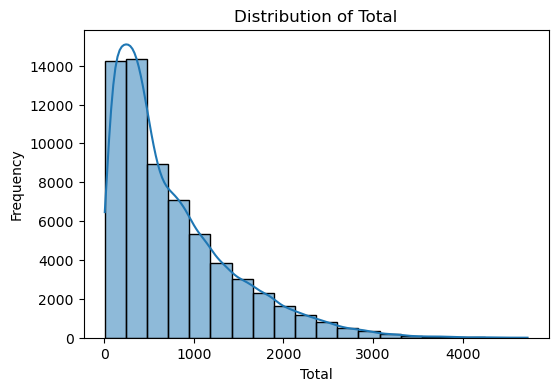

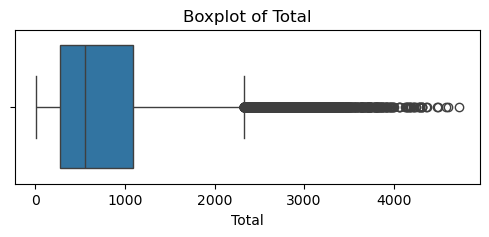


===== UnitPrice =====


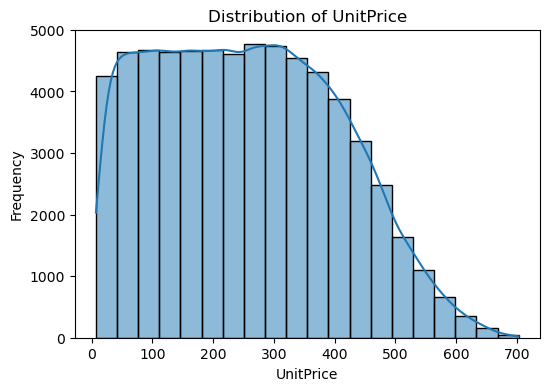

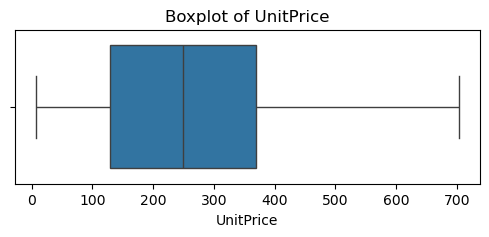

In [16]:
# --------------------------------------------------
#  Visualizing Numerical Features (Histogram + Boxplot)
# --------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    print(f"\n===== {col} =====")
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Univariate Data Analysis

### 1. Unit Price

- Summary Stats: Mean ≈ 256, Std Dev ≈ 149, Skew ≈ 0.25
- Distribution: Fairly balanced, slightly symmetric.
- Boxplot: No extreme outliers

✅ Insight: Product pricing is well-distributed without major anomalies.


#### 2. Quantity

- Summary Stats: Mean ≈ 3, Std Dev ≈ 1.66, Skew ≈ 0.54
- Distribution: Most customers buy 1–4 items.
- Boxplot: Few outliers at Quantity = 8.

✅ Insight: Purchases are small in size, bulk buying is rare.

#### 3. Total (Revenue per Transaction)

- Summary Stats: Mean ≈ 768, Std Dev ≈ 665, Skew ≈ 1.38, Kurtosis ≈ 1.9
- Distribution: Right-skewed with a long tail.
- Boxplot: Many high-value outliers (big spenders).

✅ Insight: Most transactions are moderate, but a few high spenders dominate revenue.

#### 4. Revenue Per Unit (Derived Feature)

- Mirrors Unit Price distribution.

✅ Insight: No abnormalities, consistent with pricing.

###  Overall Takeaways

- Unit Price: Balanced, no major issues.
- Quantity: Mostly 1–4 items, few large orders.
- Revenue (Total): Right-skewed → high spenders exist.
- Revenue Per Unit: Stable, consistent with pricing.

### 2. Categorical Variables


===== CustomerType =====
Unique values: 3
CustomerType
Member     39.525000
Regular    34.640625
Premium    25.834375
Name: proportion, dtype: float64


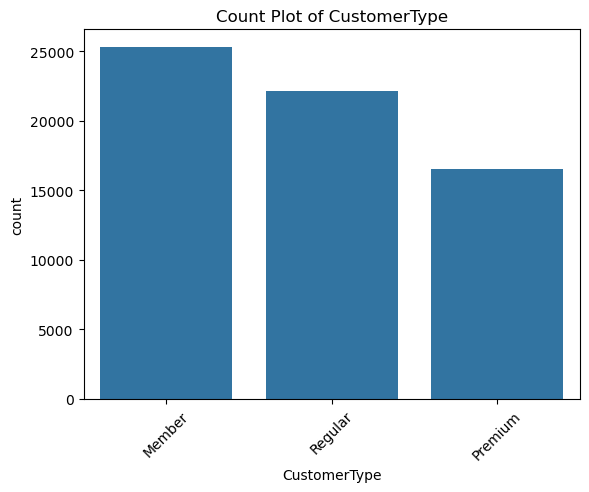


===== ProductCategory =====
Unique values: 5
ProductCategory
Home & Kitchen            24.475000
Clothing                  23.107812
Grocery                   19.414062
Beauty & Personal Care    17.320312
Electronics               15.682813
Name: proportion, dtype: float64


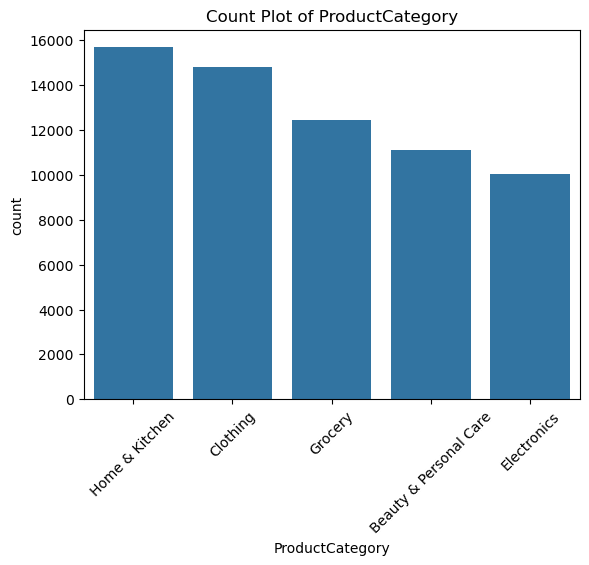


===== FullName =====
Unique values: 400
FullName
Aakash Iyer       0.309375
Ishaan Zutshi     0.300000
Jai Iyer          0.300000
Priya Kumar       0.296875
Jai Zutshi        0.295312
                    ...   
Bhavesh Wadhwa    0.206250
Avani Agarwal     0.206250
Yash Mehta        0.206250
Avani Xavier      0.198437
Uday Rao          0.184375
Name: proportion, Length: 400, dtype: float64
Count plot for Indivisuals is not required

===== DayOfWeek =====
Unique values: 7
DayOfWeek
Thursday     14.509375
Tuesday      14.496875
Sunday       14.454687
Wednesday    14.279687
Saturday     14.153125
Monday       14.118750
Friday       13.987500
Name: proportion, dtype: float64


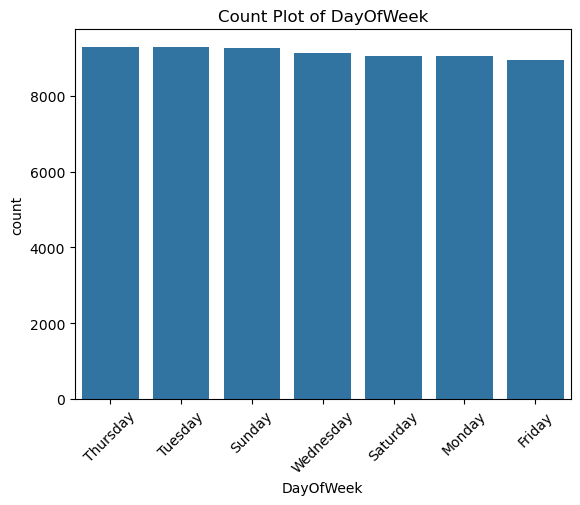


===== Month =====
Unique values: 12
Month
January      9.562500
July         8.570312
August       8.506250
December     8.504687
October      8.420312
May          8.317188
April        8.207812
March        8.167188
November     8.120313
June         8.032813
September    7.943750
February     7.646875
Name: proportion, dtype: float64


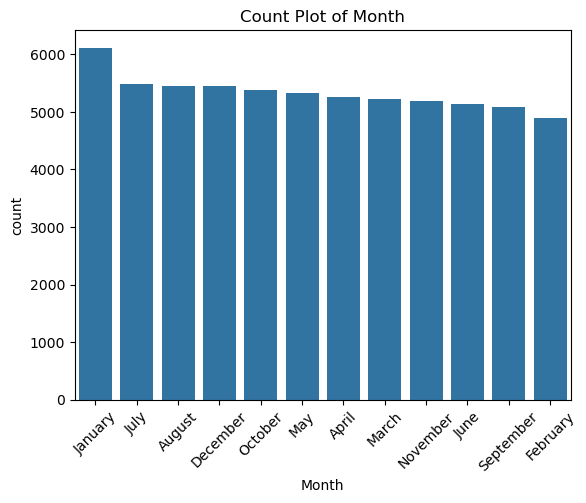


===== HighSpender =====
Unique values: 2
HighSpender
False    61.3
True     38.7
Name: proportion, dtype: float64


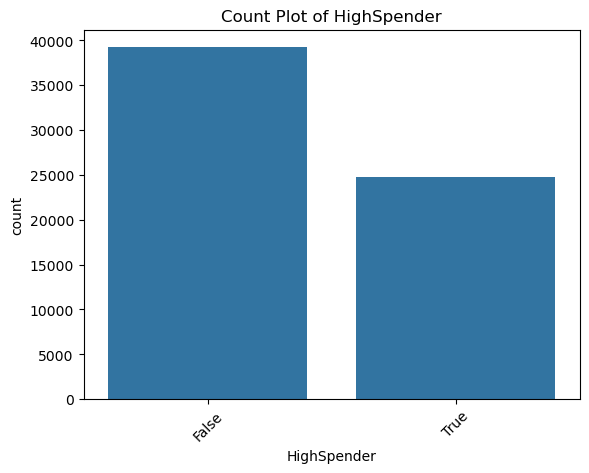

In [17]:

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(normalize=True) * 100)
    #Plot for counting
    if col=="FullName":
        print("Count plot for Indivisuals is not required") #(too many unique values)
        continue
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

### Univariate Analysis – Categorical Features

#### 1. Customer Type

- Unique values: 3
- Distribution
   - Member: 39.53%
   - Regular: 34.64%
   - Premium: 25.83%

📊 Majority of customers are Members, followed by Regulars, while Premium customers form about a quarter.

#### 2. Product Category

- Unique values: 5
- Distribution:
    - Home & Kitchen: 24.48%
    - Clothing: 23.11%
    - Grocery: 19.41%
    - Beauty & Personal Care: 17.32%
    - Electronics: 15.68%

📊 Sales are well distributed across categories, with Home & Kitchen and Clothing leading, while Electronics has the smallest share.

#### 3. Full Name

- Unique values: 400 (individual customers)
- Count plot not required as this column represents unique individuals, not meaningful categories for distribution analysis.

#### 4. Day of Week

- Unique values: 7
- Distribution:
    - Thursday: 14.51%
    - Tuesday: 14.50%
    - Sunday: 14.45%
    - Wednesday: 14.28%
    - Saturday: 14.15%
    - Monday: 14.12%
    - Friday: 13.99%

📊 Transactions are almost evenly spread across all days, with Thursday and Tuesday slightly higher and Friday slightly lower.

#### 5. Month

- Unique values: 12
- Distribution:
    - January (9.56%) has the highest transactions.
    - February (7.65%) has the lowest.
    - Other months are relatively balanced between 8–9%.

📊 Indicates a seasonal trend, with peaks in January, July, and August.

#### 6. High Spender

- Unique values: 2
- Distribution:
    - False (Regular): 61.3%
    - True (High Spender): 38.7%

📊 About 2 in 5 customers are High Spenders, suggesting a significant premium segment contributing to revenue.

###  Key Insights:

- Membership programs (Members) dominate the customer base.
- Home & Kitchen and Clothing categories drive most sales.
- Transactions are evenly spread across weekdays and weekends.
- January sees a peak, possibly due to holiday/seasonal sales.
- Nearly 40% of customers are High Spenders, a strong target segment.

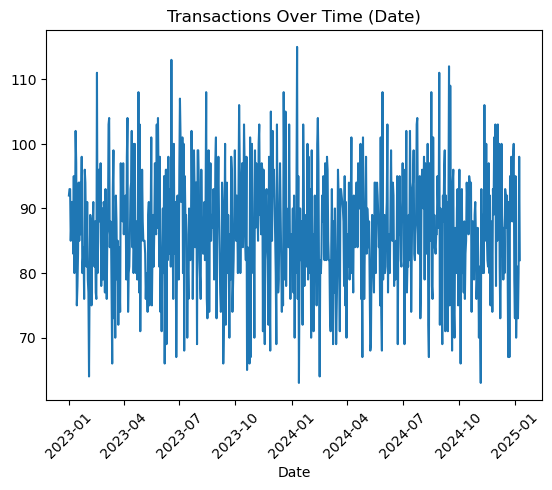

In [18]:
# Convert if needed
for col in ['Date', 'DateTime']:
    df[col] = pd.to_datetime(df[col], errors='coerce', format='%d-%m-%Y %H:%M')


# Date distribution
if 'Date' in df.columns:
    df['Date'].dt.date.value_counts().sort_index().plot()
    plt.title("Transactions Over Time (Date)")
    plt.xticks(rotation=45)
    plt.show()

###  Transaction Trends Over Time

This chart, titled "Transactions Over Time (Date)", visualizes the number of transactions recorded on a daily basis.

### Key Observations:

Consistent Activity: The number of daily transactions generally hovers between 70 and 110, indicating a stable level of business activity.

No Strong Seasonality: There isn't a clear, strong seasonal pattern (e.g., a massive spike every December). The fluctuations appear to be more random or cyclical on a smaller scale, possibly reflecting weekly patterns or minor promotional periods.

No Significant Long-Term Trend: The data appears to be relatively stationary. The average number of transactions remains consistent over the two-year period, suggesting a mature market or stable customer base without rapid growth or decline.

Minor Peaks and Valleys: There are minor peaks (e.g., around early 2024) and valleys (e.g., late 2023). These could correspond to specific events, holidays, or minor promotional campaigns.

This visualization provides a quick health check of the business's daily performance, showing stability rather than rapid change.

## BIVARIATE ANALYSIS

In [19]:
# 1. Numeric ↔ Numeric
print("\n=== Correlation Matrix ===")
corr = df[numeric_cols].corr()
print(corr)


=== Correlation Matrix ===
           UnitPrice  Quantity     Total  UnitPrice
UnitPrice   1.000000 -0.002508  0.674729   1.000000
Quantity   -0.002508  1.000000  0.635587  -0.002508
Total       0.674729  0.635587  1.000000   0.674729
UnitPrice   1.000000 -0.002508  0.674729   1.000000


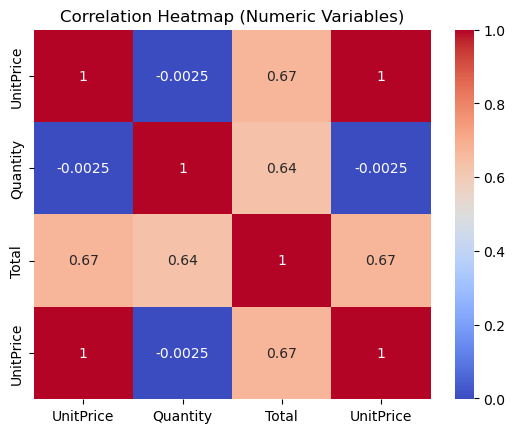

In [20]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

### Correlation Matrix Analysis

This matrix and Heatmap shows the linear relationship between numerical features, with values from -1 (negative correlation) to 1 (positive correlation).

#### Key Findings:

Total is moderately correlated with UnitPrice (0.67) and Quantity (0.64).

This confirms that both unit price and quantity significantly contribute to the total transaction amount.

UnitPrice and Quantity have an extremely weak correlation (-0.0025).

This means the price of an item does not influence the quantity a customer purchases.

RevenuePerUnit is perfectly correlated with UnitPrice (1.0).

These two columns are identical, making one redundant.

Conclusion: 

Both price and quantity drive total revenue independently of each other. The duplicate RevenuePerUnit column can be dropped for cleaner analysis.

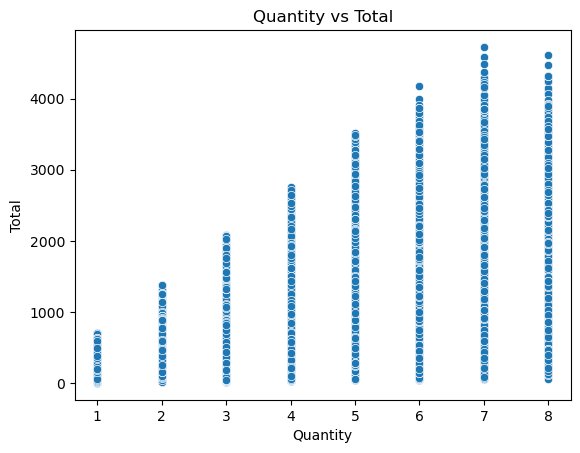

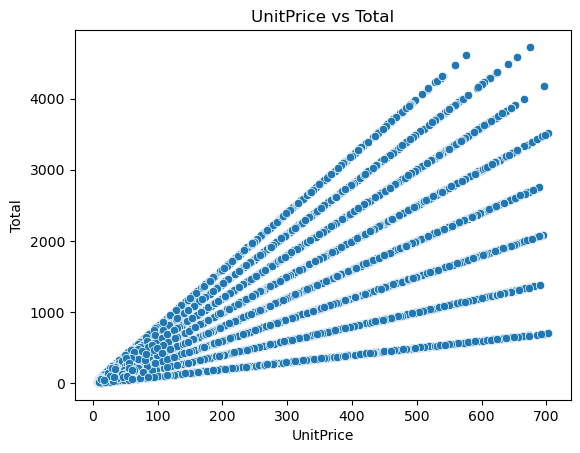

In [21]:
# Relevent Scatter plots
# Plot 1: Quantity vs Total
sns.scatterplot(x='Quantity', y='Total', data=df)
plt.title("Quantity vs Total")
plt.show()

# Plot 2: UnitPrice vs Total
sns.scatterplot(x='UnitPrice', y='Total', data=df)
plt.title("UnitPrice vs Total")
plt.show()

### Bivariate Analysis: Key Numeric Relationships

The following scatter plots visualize the most important relationships between the key numerical features: Total, Quantity, and UnitPrice.

#### 1. Quantity vs Total

This plot illustrates the direct relationship between the number of items purchased and the total transaction amount.

The plot shows distinct, vertical bands, each corresponding to a specific quantity (1, 2, 3, etc.).

Within each band, the data points are scattered, representing the range of total prices for that specific quantity.

The plot clearly demonstrates a strong positive correlation, confirming that as the number of items increases, the total transaction amount also increases. This is a fundamental and expected business insight.

#### 2. UnitPrice vs Total

This plot visualizes how the unit price of items influences the total transaction amount.

The plot reveals multiple distinct diagonal lines radiating from the origin. Each line represents a specific quantity (e.g., the lowest line is for quantity 1, the next for quantity 2, and so on).

The plot demonstrates a strong positive correlation, indicating that higher-priced items contribute to a higher total amount.

This visualization provides more detail than the Quantity vs Total plot by showing how both UnitPrice and Quantity simultaneously influence the total.

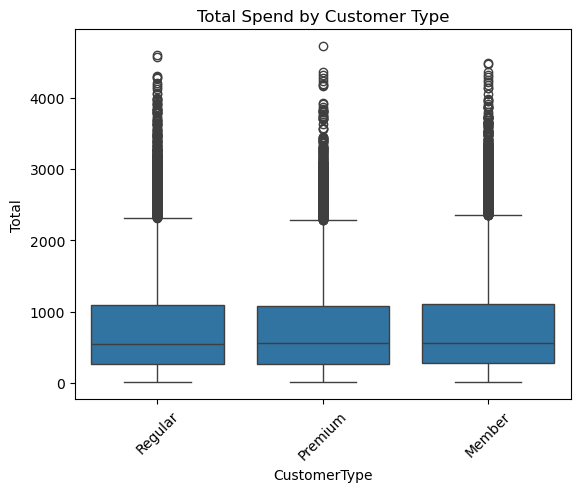

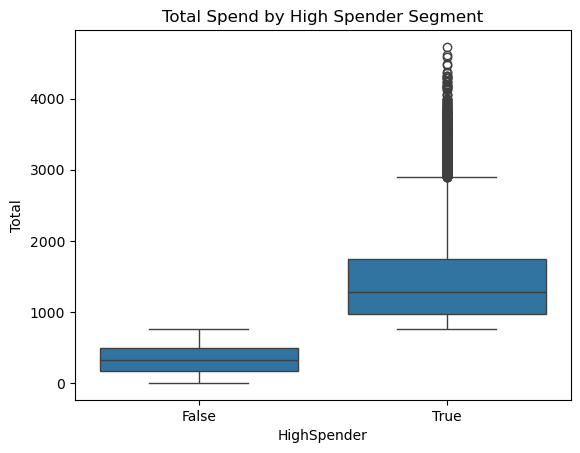

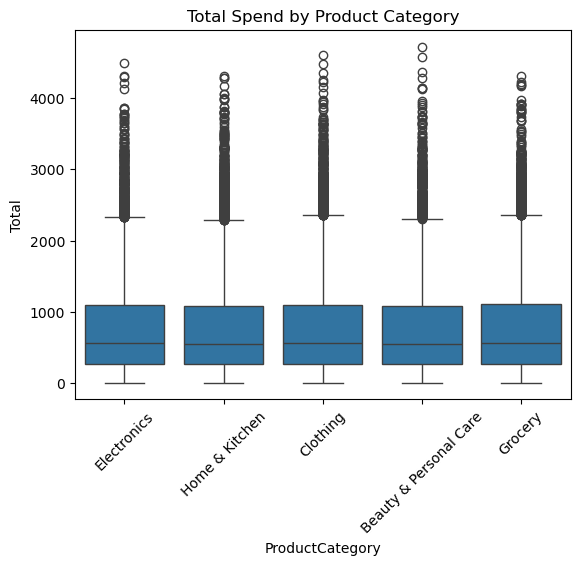

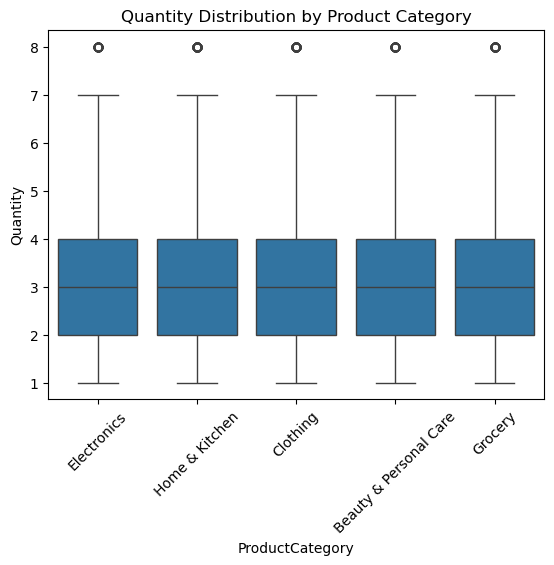

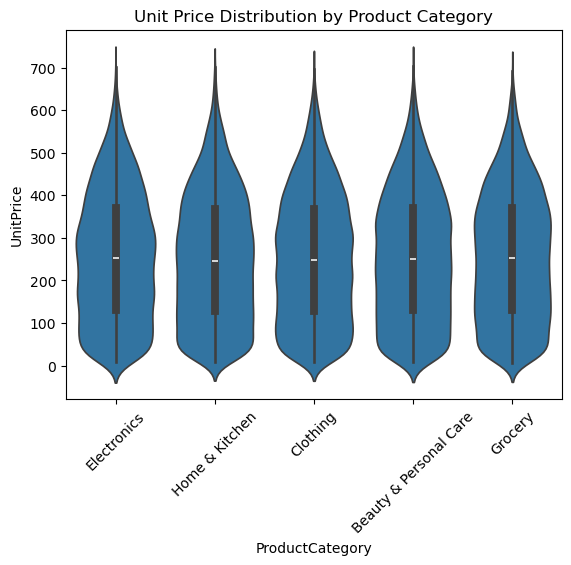

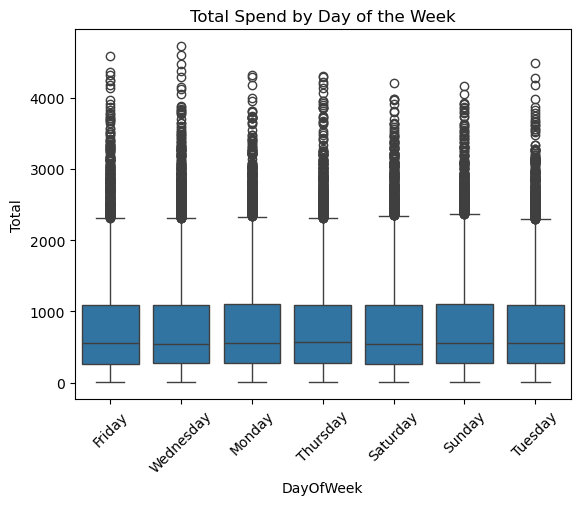

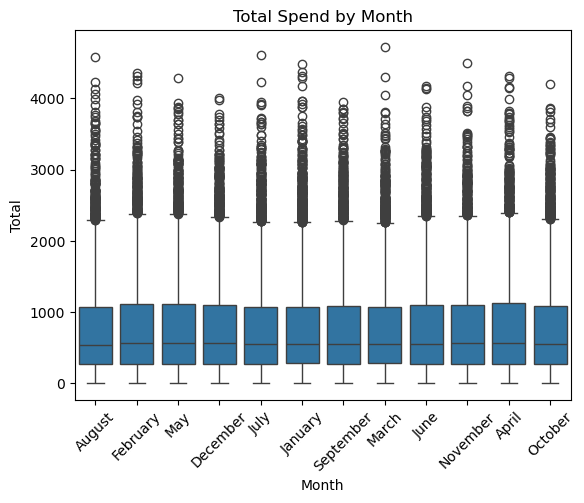

In [22]:
#Numeric ↔ Categorical
#Some Important plots
# --- 1. Revenue by Customer Segments ---
# Total spend across different customer types
sns.boxplot(x='CustomerType', y='Total', data=df)
plt.title("Total Spend by Customer Type")
plt.xticks(rotation=45)
plt.show()

# High spender segmentation
sns.boxplot(x='HighSpender', y='Total', data=df)
plt.title("Total Spend by High Spender Segment")
plt.show()


# --- 2. Product Category Insights ---
# Total spend across categories
sns.boxplot(x='ProductCategory', y='Total', data=df)
plt.title("Total Spend by Product Category")
plt.xticks(rotation=45)
plt.show()

# Quantity purchased across categories
sns.boxplot(x='ProductCategory', y='Quantity', data=df)
plt.title("Quantity Distribution by Product Category")
plt.xticks(rotation=45)
plt.show()

# Price distribution across categories
sns.violinplot(x='ProductCategory', y='UnitPrice', data=df)
plt.title("Unit Price Distribution by Product Category")
plt.xticks(rotation=45)
plt.show()


# --- 3. Time-based Patterns ---
# Sales trends across days of the week
sns.boxplot(x='DayOfWeek', y='Total', data=df)
plt.title("Total Spend by Day of the Week")
plt.xticks(rotation=45)
plt.show()

# Sales trends across months
sns.boxplot(x='Month', y='Total', data=df)
plt.title("Total Spend by Month")
plt.xticks(rotation=45)
plt.show()

###  Numeric vs. Categorical Analysis

This section explores the relationships between key numerical and categorical variables, providing a deeper understanding of spending patterns across different customer segments, product types, and time periods.

#### 1. Revenue by Customer Segments

The box plots above visualize how total spend (Total) is distributed across different customer segments.

Total Spend by Customer Type: The distributions for Regular, Premium, and Member customers are remarkably similar. All three segments have a comparable median spend (the line inside the box), interquartile range (the box itself), and a high number of outliers at the top end. This suggests that membership status does not strongly differentiate average customer spending.

Total Spend by High Spender Segment: This plot clearly shows a significant difference between High Spenders (True) and other customers (False). The median spend for High Spenders is substantially higher, and their overall spending distribution is shifted upwards. This confirms that the HighSpender classification effectively identifies a distinct group of customers who contribute a disproportionately large amount to total revenue.

#### 2. Product Category Insights

These plots analyze spending and purchasing habits across different product categories.

Total Spend by Product Category: Similar to customer types, the median spend and distribution of Total are very consistent across all product categories. There are no major differences in the average transaction amount, suggesting that customers' spending habits are not tied to the category they are shopping in.

Quantity Distribution by Product Category: This box plot shows a similar trend to the total spend. The median quantity of items purchased per transaction is consistent (around 3) across all product categories. This implies that customers buy a similar number of items, regardless of what they are shopping for.

Unit Price Distribution by Product Category: The violin plot shows the complete distribution of UnitPrice for each category. It reveals that the median unit price is similar across all categories. The shape of the "violin" is also consistent, indicating a similar spread of prices, with no single category having a uniquely high or low price range.

#### 3. Time-Based Patterns

These box plots examine whether spending habits change based on the day of the week or the month.

Total Spend by Day of the Week: The median spend and distribution of the Total amount remain very consistent across all days of the week. There is no significant difference in how much customers spend on a Monday versus a Sunday.

Total Spend by Month: Just like the daily analysis, this plot shows a stable spending pattern throughout the year. The median spend and distribution for each month are nearly identical, with no obvious seasonal spikes or dips in transaction value.

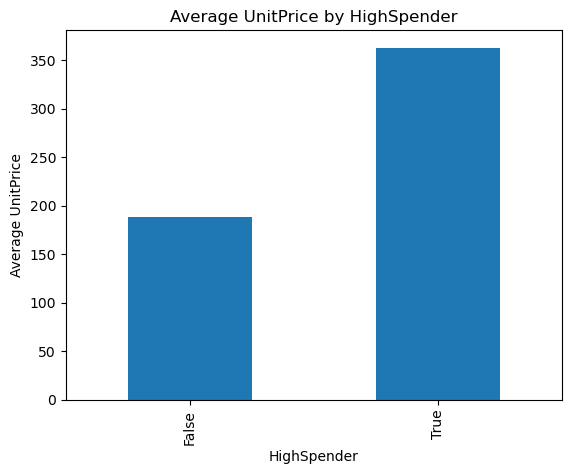

In [23]:
# Grouped mean
grouped_mean = df.groupby('HighSpender')['UnitPrice'].mean().sort_values()
grouped_mean.plot(kind='bar')
plt.title(f"Average {'UnitPrice'} by {'HighSpender'}")
plt.ylabel(f"Average {'UnitPrice'}")
plt.show()

#### High Spender Analysis

This bar chart shows the average revenue per unit across different segments of customers. We've divided customers into two groups: those we've identified as HighSpender and those who are not.

The plot makes it clear that High Spenders generate significantly more revenue per unit sold than non-high spenders. While non-high spenders bring in an average of around 
360—nearly double the amount. This reinforces that this segment is crucial for the business, as they not only spend more overall but also buy higher-priced items.

#### 3. Categorical ↔ Categorical

#### Customer Type Analysis

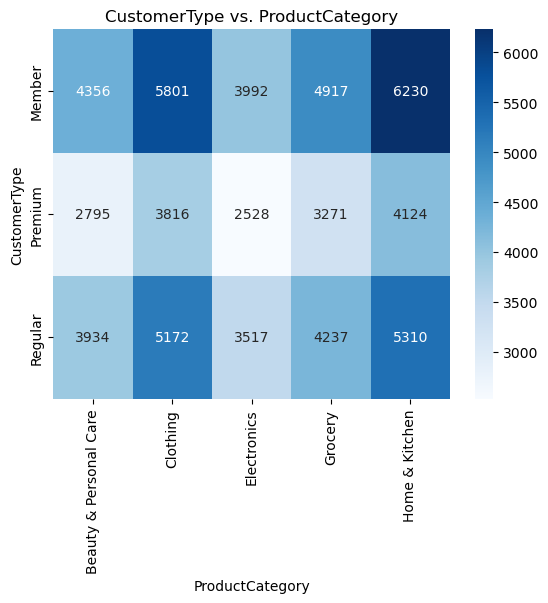

In [24]:
# CustomerType vs. ProductCategory
ctab_cust_prod = pd.crosstab(df['CustomerType'], df['ProductCategory'])
sns.heatmap(ctab_cust_prod, annot=True, fmt="d", cmap='Blues')
plt.title("CustomerType vs. ProductCategory")
plt.show()

#### What Are People Buying?

This heatmap shows us which product categories are most popular, broken down by customer type.

Top Categories: Home & Kitchen and Clothing are our best-selling categories, with all customer types buying from them most often.

Ranking: Here's the order of categories by total transactions:

- Home & Kitchen
- Clothing
- Grocery
- Beauty & Personal Care
- Electronics

Key Insight: Our customers' buying habits are consistent across the board. They're not loyal to specific categories based on their membership status.

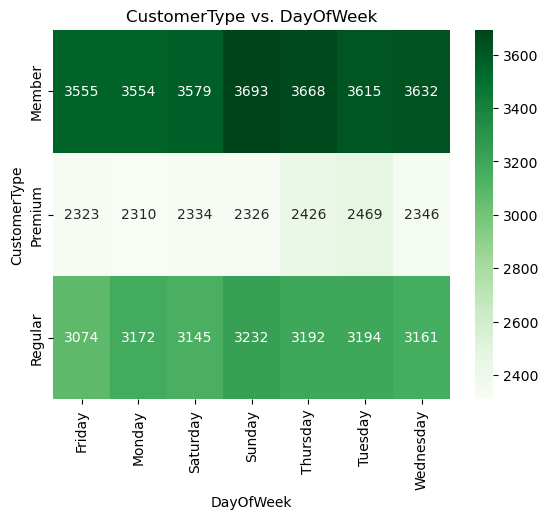

In [25]:
# CustomerType vs. DayOfWeek
ctab_cust_day = pd.crosstab(df['CustomerType'], df['DayOfWeek'])
sns.heatmap(ctab_cust_day, annot=True, fmt="d", cmap='Greens')
plt.title("CustomerType vs. DayOfWeek")
plt.show()

####  When Do Customers Shop?

This heatmap shows us the number of transactions for each customer type on different days of the week.

Stable Shopping: All customer types shop consistently throughout the week. There are no major spikes on weekends or specific days.

Top 3 Days: Our busiest days, though only slightly, are:

- Thursday (9,286 transactions)
- Tuesday (9,278 transactions)
- Sunday (9,251 transactions)

Key Insight: This predictability in daily sales is great for business operations, making staffing and stock management easier.

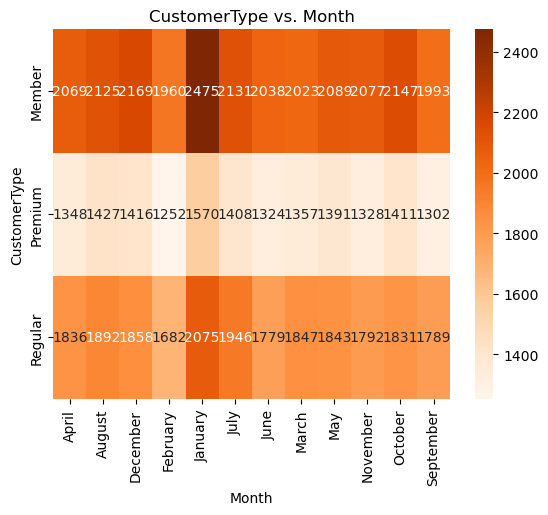

In [26]:
# CustomerType vs. Month
ctab_cust_month = pd.crosstab(df['CustomerType'], df['Month'])
sns.heatmap(ctab_cust_month, annot=True, fmt="d", cmap='Oranges')
plt.title("CustomerType vs. Month")
plt.show()

#### Customer spending patterns are consistent and predictable.

No Seasonal or Weekly Trends: The Total Spend by Month and Total Spend by Day of the Week plots show that spending distributions are very similar throughout the year and across all days of the week. This indicates stable and predictable customer behavior, which is ideal for inventory and staffing management.

Valuable High Spenders: The Total Spend by High Spender Segment box plot reveals a distinct group of customers who spend significantly more per transaction. While their numbers are fewer, their high transaction value makes them crucial to the business.

Loyalty Tiers Don't Drive Spending: The Total Spend by Customer Type plot shows that Member, Premium, and Regular customers have very similar median spending. This suggests that the current loyalty program tiers are not effectively incentivizing higher per-transaction spending.

Product Preferences are Consistent: The Total Spend by Product Category plot indicates that customers' spending habits are not strongly tied to the product category they shop in. The average transaction value is consistent across all product types.

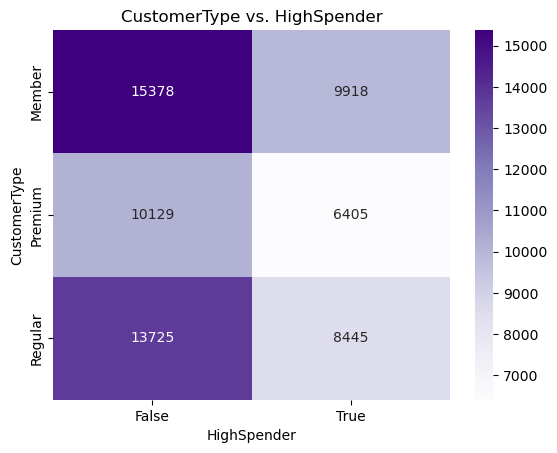

In [27]:
# CustomerType vs. HighSpender
ctab_cust_high = pd.crosstab(df['CustomerType'], df['HighSpender'])
sns.heatmap(ctab_cust_high, annot=True, fmt="d", cmap='Purples')
plt.title("CustomerType vs. HighSpender")
plt.show()

#### Customer Type vs. High Spender

This heatmap shows how many customers of each type are classified as HighSpender.

The data reveals a consistent ratio: about 38% to 39% of customers are high spenders in every customer group.

- Members: 9,918 are High Spenders (39.2%).
- Premium: 6,405 are High Spenders (38.7%).
- Regular: 8,445 are High Spenders (38.1%).

Key Insight: Being a Member or Premium customer doesn't make a person more likely to be a high spender. This valuable segment exists across all customer tiers

#### Product Category Analysis

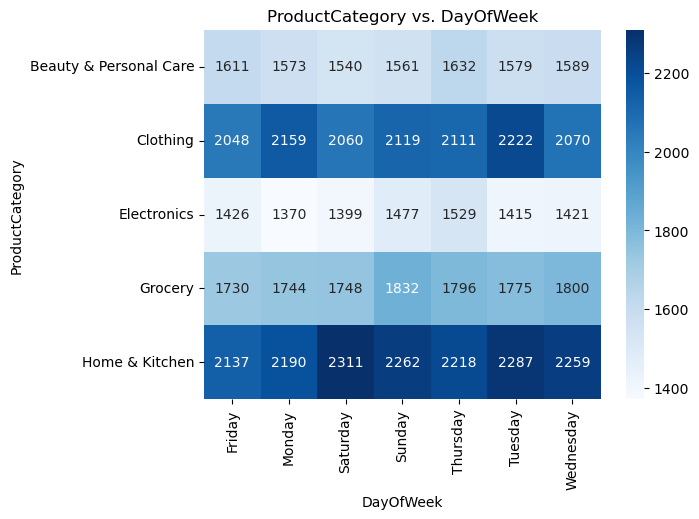

In [28]:
# ProductCategory vs. DayOfWeek
ctab_prod_day = pd.crosstab(df['ProductCategory'], df['DayOfWeek'])
sns.heatmap(ctab_prod_day, annot=True, fmt="d", cmap='Blues')
plt.title("ProductCategory vs. DayOfWeek")
plt.show()


High Spenders are Key: Our most valuable customers are the High Spenders, who spend significantly more per transaction than everyone else. This segment exists across all customer types (Member, Premium, Regular).

Predictable Sales: Sales are highly stable and consistent. There are no major spikes or dips based on the day of the week or the month, making forecasting and operations straightforward.

Loyalty Programs Need a Look: The current loyalty tiers don't seem to drive higher spending per visit, as average transaction amounts are similar across all customer types.

Consistent Customer Behavior: Customer spending and purchasing habits are uniform. The average transaction value, unit price, and quantity of items are all consistent across product categories.

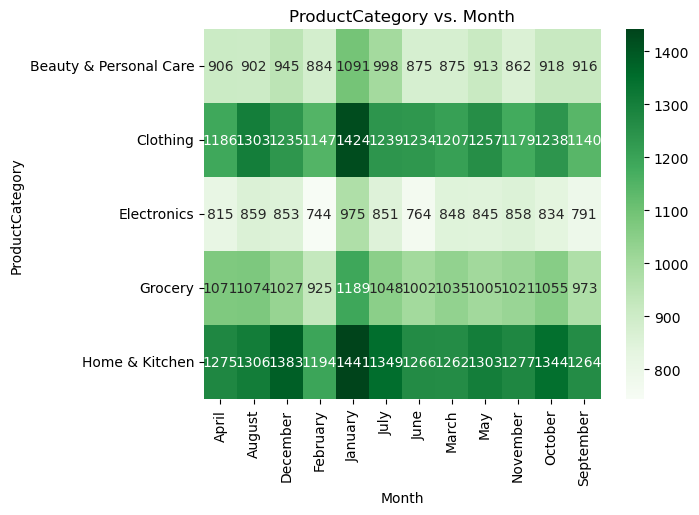

In [29]:
# ProductCategory vs. Month
ctab_prod_month = pd.crosstab(df['ProductCategory'], df['Month'])
sns.heatmap(ctab_prod_month, annot=True, fmt="d", cmap='Greens')
plt.title("ProductCategory vs. Month")
plt.show()

#### Product Category vs. Day of Week

This heatmap shows how many transactions occurred for each product category on different days.

The numbers are remarkably consistent across all days of the week for every category. There are no major sales spikes on weekends or any particular weekday.

Home & Kitchen and Clothing consistently have the highest transaction counts, regardless of the day.

Electronics consistently has the lowest transaction count.

This analysis confirms that product sales are stable on any given day, making it easy to predict demand.

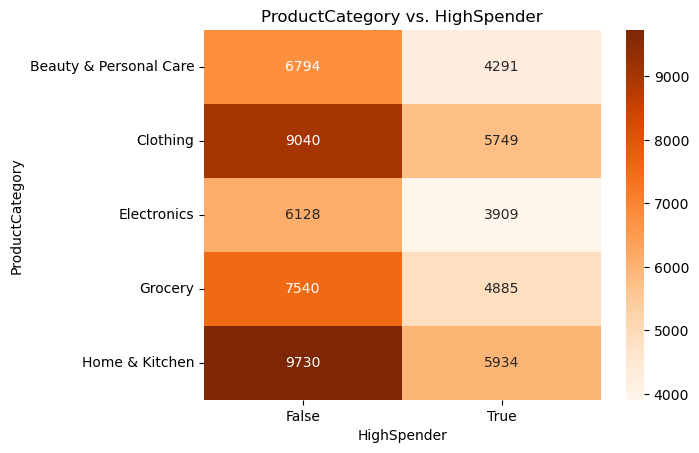

In [30]:
# ProductCategory vs. HighSpender
ctab_prod_high = pd.crosstab(df['ProductCategory'], df['HighSpender'])
sns.heatmap(ctab_prod_high, annot=True, fmt="d", cmap='Oranges')
plt.title("ProductCategory vs. HighSpender")
plt.show()


Based on the ProductCategory vs. HighSpender heatmap, here are the top categories where high spenders spend their money, ranked by the number of transactions:

Home & Kitchen (5,934 transactions)

- Clothing (5,749 transactions)
- Grocery (4,885 transactions)
- Beauty & Personal Care (4,291 transactions)
- Electronics (3,909 transactions)

Key Insight: High spenders show the same purchasing patterns as the general customer base, with Home & Kitchen and Clothing being their top choices. This means you don't need a separate product strategy to attract high spenders; they are already buying your most popular items.

#### Time & High Spender Analysis

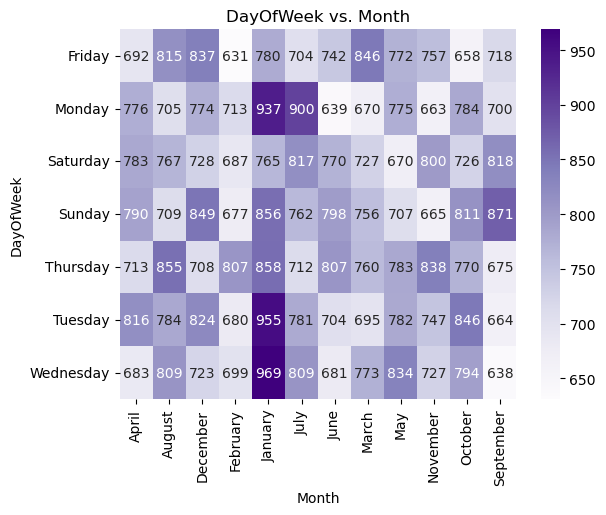

In [31]:
# DayOfWeek vs. Month
ctab_day_month = pd.crosstab(df['DayOfWeek'], df['Month'])
sns.heatmap(ctab_day_month, annot=True, fmt="d", cmap='Purples')
plt.title("DayOfWeek vs. Month")
plt.show()

#### Key Business Insights

High Spenders are Key: Our most valuable customers are the High Spenders, who spend significantly more per transaction. This segment exists consistently across all customer types (Member, Premium, Regular).

Predictable Sales: Sales are highly stable and consistent. There are no major spikes or dips based on the day of the week or the month, making forecasting and operations straightforward.

Loyalty Programs Need a Look: The current loyalty tiers don't seem to drive higher spending per visit, as average transaction amounts are similar across all customer types.

Consistent Customer Behavior: Customer spending and purchasing habits are uniform. The average transaction value, unit price, and quantity of items are all consistent across product categories.

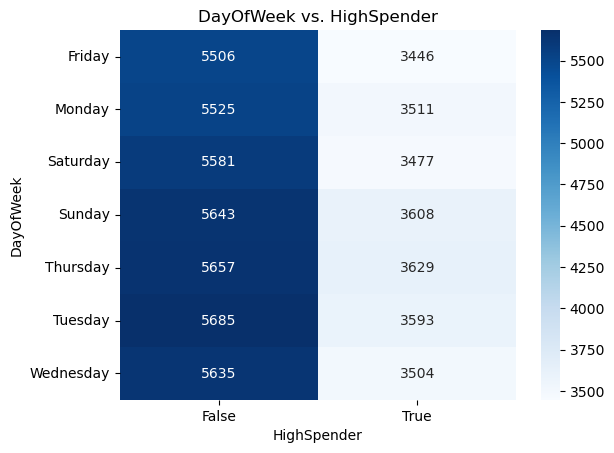

In [32]:
# DayOfWeek vs. HighSpender
ctab_day_high = pd.crosstab(df['DayOfWeek'], df['HighSpender'])
sns.heatmap(ctab_day_high, annot=True, fmt="d", cmap='Blues')
plt.title("DayOfWeek vs. HighSpender")
plt.show()


#### When Do Customers Shop?

This heatmap shows the number of transactions from high spenders and non-high spenders on each day of the week. The data reveals that both groups follow a very similar shopping pattern.

#### Top 3 Days for High Spenders 💰

- Thursday (3,629 transactions)
- Sunday (3,608 transactions)
- Tuesday (3,593 transactions)

#### Top 3 Days for Non-High Spenders 

- Tuesday (5,685 transactions)
- Thursday (5,657 transactions)
- Sunday (5,643 transactions)

Key Insight: High spenders and non-high spenders visit the store on the same days, with Tuesday, Thursday, and Sunday being the most popular. This means you don't need a separate strategy to attract high spenders on different days—their shopping habits align with the general customer base.

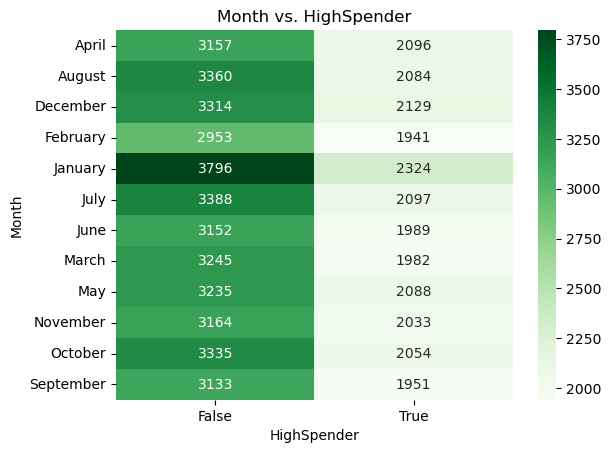

In [33]:
# Month vs. HighSpender
ctab_month_high = pd.crosstab(df['Month'], df['HighSpender'])
sns.heatmap(ctab_month_high, annot=True, fmt="d", cmap='Greens')
plt.title("Month vs. HighSpender")
plt.show()

#### The data reveals two main insights:

Predictable and Stable Sales: Transaction volumes and spending are highly consistent across the board. The number of sales and average transaction size don't fluctuate much by Day of the Week or Month. This makes forecasting and managing operations easier.

Customer Segmentation is Key: While loyalty tiers (Member, Premium) don't seem to drive higher spending, the High Spender segment is extremely valuable. The data confirms they spend significantly more per transaction, making them a crucial group for targeted marketing and retention.

### Loading the data in SQL

In [34]:
pip list

Package                           Version
--------------------------------- --------------------
aiobotocore                       2.25.0
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.2
aioitertools                      0.12.0
aiosignal                         1.4.0
alabaster                         0.7.16
altair                            5.5.0
anaconda-anon-usage               0.7.5
anaconda-auth                     0.12.3
anaconda-catalogs                 0.2.0
anaconda-cli-base                 0.7.0
anaconda-client                   1.14.0
anaconda-navigator                2.7.0
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.10.0
appdirs                           1.4.4
archspec                          0.2.5
argon2-cffi                       21.3.0
argon2-cffi-bindings              25.1.0
arrow                             1.4.0
astroid      

#### Switching to a Relational Database: SQL with SQLite

We've just finished our visual exploration using Python. Now, let's take a different approach by treating our dataset as a relational database. We'll use SQL (Structured Query Language), the industry-standard language for interacting with databases.

For this, we'll use SQLite, a fast and lightweight database engine that works directly with Python. It allows us to run powerful queries on our data without needing to set up a full database server.

The following section contains 10 SQL questions designed to reinforce the insights we've already found and to practice key SQL concepts like SELECT, GROUP BY, ORDER BY, and aggregate functions (SUM, COUNT, AVG).

In [35]:
# We will use the sqlalchemy and pymysql to load the processed data in SQL

from sqlalchemy import create_engine
import sqlite3

#creating SQLite connection
engine_sales = create_engine("sqlite:///sales_data.db")

#Now we load the data in a AQL table
df.to_sql("Sales_table",con=engine_sales,if_exists="replace",index = False)


print("Data loaded into SQLite successfully!")

Data loaded into SQLite successfully!


In [36]:
#cheking 
pd.read_sql("SELECT * FROM sales_table LIMIT 5;", engine_sales)

,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName,DateTime,DayOfWeek,Month,Hour,RevenuePerUnit,HighSpender
0,2024-08-30 06:07:00.000000,16:06:50,Regular,Electronics,142.494909,2,284.99,Avani Iyer,2024-08-30 16:06:50.000000,Friday,August,16,142.495,0
1,2023-02-22 19:48:00.000000,22:51:46,Regular,Home & Kitchen,462.398027,1,462.40,Tanvi Jain,2023-02-22 22:51:46.000000,Wednesday,February,22,462.400,0
2,2024-05-13 04:29:00.000000,11:48:46,Regular,Clothing,64.137199,5,320.69,Eeshaan Patel,2024-05-13 11:48:46.000000,Monday,May,11,64.138,0
3,2023-12-27 16:09:00.000000,02:34:39,Premium,Clothing,114.809421,2,229.62,Eeshaan Kumar,2023-12-27 02:34:39.000000,Wednesday,December,2,114.810,0
4,2024-07-05 23:40:00.000000,10:22:35,Premium,Home & Kitchen,120.361725,1,120.36,Gaurav Rao,2024-07-05 10:22:35.000000,Friday,July,10,120.360,0


In [37]:
# 1️⃣ Total Revenue per Product Category

Q1 = """
SELECT ProductCategory, 
       SUM(Total) AS TotalRevenue
FROM sales_table
GROUP BY ProductCategory
ORDER BY TotalRevenue DESC;
"""
pd.read_sql(Q1, engine_sales)

,ProductCategory,TotalRevenue
0,Home & Kitchen,11863993.74
1,Clothing,11418508.77
2,Grocery,9636949.28
3,Beauty & Personal Care,8539563.53
4,Electronics,7712167.28


In [38]:
# 2️⃣ Average Basket Size per Customer Type
Q2 = """
SELECT CustomerType, 
       ROUND(AVG(Quantity), 2) AS AvgQuantity
FROM sales_table
GROUP BY CustomerType;
"""
pd.read_sql(Q2, engine_sales)

,CustomerType,AvgQuantity
0,Member,3.02
1,Premium,3.00
2,Regular,2.99


In [39]:
# 3️⃣ Top 10 Highest Spending Customers
Q3 = """
SELECT FullName, 
       SUM(Total) AS CustomerSpend
FROM sales_table
GROUP BY FullName
ORDER BY CustomerSpend DESC
LIMIT 10;
"""
pd.read_sql(Q3, engine_sales)

,FullName,CustomerSpend
0,Aakash Iyer,164316.21
1,Uday Mehta,156208.63
2,Lakshmi Xavier,154136.48
3,Diya Yadav,152725.07
4,Mahesh Xavier,152321.55
5,Jai Desai,150439.79
6,Eeshaan Yadav,149820.94
7,Eeshaan Kumar,149536.07
8,Aakash Khanna,148995.02
9,Priya Zutshi,148722.96


In [40]:
# 4️⃣ Revenue Trend by Month
Q4 = """
SELECT Month, 
       SUM(Total) AS TotalRevenue
FROM sales_table
GROUP BY Month
ORDER BY Month;
"""
pd.read_sql(Q4, engine_sales)

,Month,TotalRevenue
0,April,4125178.78
1,August,4117253.64
2,December,4182087.95
3,February,3816131.55
4,January,4674418.17
5,July,4171236.78
6,June,3960149.98
7,March,3970419.95
8,May,4117299.05
9,November,4012139.08


In [41]:
# 5️⃣ Sales Count by Day of the Week
Q5 = """
SELECT DayOfWeek, 
       COUNT(*) AS Transactions
FROM sales_table
GROUP BY DayOfWeek
ORDER BY Transactions DESC;
"""
pd.read_sql(Q5, engine_sales)

,DayOfWeek,Transactions
0,Thursday,9286
1,Tuesday,9278
2,Sunday,9251
3,Wednesday,9139
4,Saturday,9058
5,Monday,9036
6,Friday,8952


In [42]:
# Q6: Month-wise revenue & growth percent (ordered Jan–Dec)
Q6 = """
SELECT 
    Month,
    Revenue,
    ROUND(((Revenue - LAG(Revenue) OVER (ORDER BY MonthNum)) * 100.0 /
           LAG(Revenue) OVER (ORDER BY MonthNum)), 2) AS GrowthPercent
FROM (
    SELECT 
        Month,
        SUM(Total) AS Revenue,
        CASE 
            WHEN Month IN ('Jan','January') THEN 1
            WHEN Month IN ('Feb','February') THEN 2
            WHEN Month IN ('Mar','March') THEN 3
            WHEN Month IN ('Apr','April') THEN 4
            WHEN Month = 'May' THEN 5
            WHEN Month IN ('Jun','June') THEN 6
            WHEN Month IN ('Jul','July') THEN 7
            WHEN Month IN ('Aug','August') THEN 8
            WHEN Month IN ('Sep','September') THEN 9
            WHEN Month IN ('Oct','October') THEN 10
            WHEN Month IN ('Nov','November') THEN 11
            WHEN Month IN ('Dec','December') THEN 12
        END AS MonthNum
    FROM sales_table
    GROUP BY Month
) 
ORDER BY MonthNum
"""
pd.read_sql(Q6, engine_sales)

,Month,Revenue,GrowthPercent
0,January,4674418.17,NaN
1,February,3816131.55,-18.36
2,March,3970419.95,4.04
3,April,4125178.78,3.90
4,May,4117299.05,-0.19
5,June,3960149.98,-3.82
6,July,4171236.78,5.33
7,August,4117253.64,-1.29
8,September,3912245.08,-4.98
9,October,4112622.59,5.12


In [43]:
# Q7: Customer type spending comparison between weekends and weekdays
Q7 = """
SELECT CustomerType,
       ROUND(SUM(CASE WHEN DayOfWeek IN ('Saturday', 'Sunday') THEN Total ELSE 0 END), 2) AS WeekendRevenue,
       ROUND(SUM(CASE WHEN DayOfWeek NOT IN ('Saturday', 'Sunday') THEN Total ELSE 0 END), 2) AS WeekdayRevenue
FROM sales_table
GROUP BY CustomerType
"""
pd.read_sql(Q7, engine_sales)

,CustomerType,WeekendRevenue,WeekdayRevenue
0,Member,5691408.97,13952261.79
1,Premium,3581263.79,9074895.18
2,Regular,4826336.72,12045016.15


In [44]:
# Q7: Customers whose spending is above their customer type's average
Q8 = """
SELECT s.CustomerType, s.FullName, SUM(s.Total) AS TotalSpent
FROM sales_table s
GROUP BY s.CustomerType, s.FullName
HAVING SUM(s.Total) > (
    SELECT AVG(total_spent)
    FROM (
        SELECT CustomerType, SUM(Total) AS total_spent
        FROM sales_table
        GROUP BY CustomerType, FullName
    ) sub
    WHERE sub.CustomerType = s.CustomerType
)
ORDER BY s.CustomerType, TotalSpent DESC
"""
pd.read_sql(Q8, engine_sales)

,CustomerType,FullName,TotalSpent
0,Member,Bhavesh Khanna,77181.57
1,Member,Shreya Jain,75651.48
2,Member,Tanvi Singh,74674.09
3,Member,Gaurav Singh,73409.71
4,Member,Aakash Iyer,70275.17
...,...,...,...
579,Regular,Gaurav Sharma,42498.03
580,Regular,Aakash Desai,42443.39
581,Regular,Aakash Sharma,42314.24
582,Regular,Krishna Verma,42296.80


In [45]:
# Q9: Revenue share percentage of each product category
Q9 = """
SELECT ProductCategory,
       ROUND((SUM(Total) * 100.0 / (SELECT SUM(Total) FROM sales_table)), 2) AS RevenueSharePercent
FROM sales_table
GROUP BY ProductCategory
ORDER BY RevenueSharePercent DESC
"""
pd.read_sql(Q9, engine_sales)

,ProductCategory,RevenueSharePercent
0,Home & Kitchen,24.13
1,Clothing,23.22
2,Grocery,19.60
3,Beauty & Personal Care,17.37
4,Electronics,15.68


In [46]:
# Q10: Find the most popular hour for each day of the week
Q10 = """
SELECT DayOfWeek, Hour, TotalSales
FROM (
    SELECT DayOfWeek, Hour, SUM(Total) AS TotalSales,
           ROW_NUMBER() OVER (PARTITION BY DayOfWeek ORDER BY SUM(Total) DESC) AS rn
    FROM sales_table
    GROUP BY DayOfWeek, Hour
) t
WHERE rn = 1
"""
pd.read_sql(Q10, engine_sales)

,DayOfWeek,Hour,TotalSales
0,Friday,19,353278.58
1,Monday,18,325223.53
2,Saturday,9,326327.16
3,Sunday,23,329228.30
4,Thursday,3,331959.39
5,Tuesday,5,329159.49
6,Wednesday,6,336480.14


In [47]:
# Q11: Identify the top 3 customers per product category based on total spending
Q11 = """
SELECT ProductCategory, FullName, TotalSpent
FROM (
    SELECT 
        ProductCategory, 
        FullName, 
        SUM(Total) AS TotalSpent,
        RANK() OVER (PARTITION BY ProductCategory ORDER BY SUM(Total) DESC) AS rnk
    FROM sales_table
    GROUP BY ProductCategory, FullName
)
WHERE rnk <= 3
"""
pd.read_sql(Q11, engine_sales)

,ProductCategory,FullName,TotalSpent
0,Beauty & Personal Care,Mahesh Xavier,38103.40
1,Beauty & Personal Care,Eeshaan Bhatia,37980.11
2,Beauty & Personal Care,Diya Patel,37867.54
3,Clothing,Diya Verma,49142.38
4,Clothing,Yash Xavier,45466.83
5,Clothing,Mahesh Rao,44905.21
6,Electronics,Bhavesh Chauhan,34678.96
7,Electronics,Gaurav Rao,31847.91
8,Electronics,Vaibhav Chauhan,31761.85
9,Grocery,Mahesh Bhatia,42025.74


#### Visual Storytelling with Tableau

With our data cleaned, analyzed, and organized in Excel, the next step is to transform our findings into interactive visualizations and dashboards using Tableau.

Tableau is the industry-leading business intelligence tool that allows us to connect to our data and create compelling, shareable insights without writing a single line of code. We will use the Excel file we just created as our data source to build dynamic charts and dashboards that a business user can easily explore.

This final phase will turn our data analysis into a powerful visual narrative, providing stakeholders with an intuitive way to understand customer behavior and make data-driven decisions.

In [48]:
df_q1 = pd.read_sql(Q1, engine_sales)
df_q1.to_sql("Q1", engine_sales, if_exists="replace", index=False)

df_q2 = pd.read_sql(Q2, engine_sales)
df_q2.to_sql("Q2", engine_sales, if_exists="replace", index=False)

df_q3 = pd.read_sql(Q3, engine_sales)
df_q3.to_sql("Q3", engine_sales, if_exists="replace", index=False)

df_q4 = pd.read_sql(Q4, engine_sales)
df_q4.to_sql("Q4", engine_sales, if_exists="replace", index=False)

df_q5 = pd.read_sql(Q5, engine_sales)
df_q5.to_sql("Q5", engine_sales, if_exists="replace", index=False)

df_q6 = pd.read_sql(Q6, engine_sales)
df_q6.to_sql("Q6", engine_sales, if_exists="replace", index=False)

df_q7 = pd.read_sql(Q7, engine_sales)
df_q7.to_sql("Q7", engine_sales, if_exists="replace", index=False)

df_q8 = pd.read_sql(Q8, engine_sales)
df_q8.to_sql("Q8", engine_sales, if_exists="replace", index=False)

df_q9 = pd.read_sql(Q9, engine_sales)
df_q9.to_sql("Q9", engine_sales, if_exists="replace", index=False)

df_q10 = pd.read_sql(Q10, engine_sales)
df_q10.to_sql("Q10", engine_sales, if_exists="replace", index=False)

7

In [49]:
df_q11 = pd.read_sql(Q11, engine_sales)
df_q11.to_sql("Q11", engine_sales, if_exists="replace", index=False)


15

#### NOW WE WILL CHECK if this is ready

In [50]:
from sqlalchemy import inspect

ins_sales = inspect(engine_sales)
print(ins_sales.get_table_names())

['Q1', 'Q10', 'Q11', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Sales_table']


In [51]:
# Example for all queries Q1–Q11
query_dict = {
    "Q1": Q1,
    "Q2": Q2,
    "Q3": Q3,
    "Q4": Q4,
    "Q5": Q5,
    "Q6": Q6,
    "Q7": Q7,
    "Q8": Q8,
    "Q9": Q9,
    "Q10": Q10,
    "Q11": Q11
}

for name, query in query_dict.items():
    df_result = pd.read_sql(query, engine_sales)
    df_result.to_sql(name, con=engine_sales, if_exists="replace", index=False)

print("All queries saved to SQLite!")

All queries saved to SQLite!


In [52]:
tables = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10','Q11','Sales_table']

with pd.ExcelWriter("sales_analysis_queries.xlsx", engine='openpyxl') as writer:
    for table in tables:
        df = pd.read_sql(f"SELECT * FROM {table}", engine_sales)
        df.to_excel(writer, sheet_name=table, index=False)

print("All tables exported into one Excel file (multi-sheet) successfully!")

All tables exported into one Excel file (multi-sheet) successfully!
